<a href="https://colab.research.google.com/github/mcnica89/DATA6100/blob/main/Non_linear_stuff_in_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Desmos Links

https://www.desmos.com/calculator/vykcjbg8kr

https://www.desmos.com/calculator/m8yr3fnh39

# Example 1

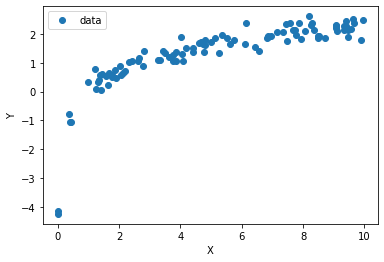

In [2]:
def generate_data_1(N):
  t_f = 10
  t_min = 5
  X = np.random.rand(N)*t_f
  Y = np.log(X) + 0.25*np.random.randn(N)
  return X,Y

N = 100
X,Y = generate_data_1(N)

def simple_plot(X,Y,my_label='data'):
  plt.plot(X,Y,'o',label=my_label)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.legend()

simple_plot(X,Y)

In [3]:
#For importing into google sheets -> desmos
def print_data(X,Y):
  for i in range(len(X)):
    print(f'{X[i]:.2f}, {Y[i]:.2f}')

print_data(X,Y)

2.44, 1.05
9.40, 2.26
7.46, 1.75
9.32, 2.12
8.27, 2.30
6.82, 1.84
1.40, 0.04
3.77, 1.26
5.25, 1.33
1.57, 0.52
4.81, 1.79
9.12, 2.10
9.07, 2.30
1.35, 0.39
8.48, 1.94
1.66, 0.63
2.32, 1.01
6.97, 1.91
2.06, 0.57
1.32, 0.34
5.00, 1.73
0.01, -4.24
6.85, 1.90
5.62, 1.63
9.41, 2.43
7.78, 1.96
7.74, 2.14
6.86, 1.92
2.61, 1.04
9.94, 2.47
4.79, 1.60
0.02, -4.12
4.78, 1.37
9.35, 2.28
8.37, 2.14
9.47, 1.90
7.46, 2.32
1.20, 0.78
1.26, 0.08
4.19, 1.51
0.42, -1.07
7.36, 2.07
5.75, 1.78
4.40, 1.51
9.67, 2.37
4.68, 1.73
0.40, -1.04
9.07, 2.26
5.35, 1.96
1.37, 0.56
4.07, 1.07
4.01, 1.88
8.06, 2.10
7.88, 2.37
4.59, 1.67
1.63, 0.23
7.66, 2.14
1.76, 0.57
4.42, 1.36
4.04, 1.31
3.35, 1.10
2.03, 0.88
2.64, 1.17
6.55, 1.40
6.12, 1.64
5.13, 1.85
9.56, 2.18
9.09, 2.19
8.47, 1.86
7.93, 1.83
1.76, 0.50
2.19, 0.71
7.15, 2.05
3.76, 1.07
9.64, 2.51
4.75, 1.65
1.87, 0.73
6.42, 1.53
0.35, -0.76
3.50, 1.33
6.14, 2.37
2.80, 1.41
8.70, 1.84
3.86, 1.06
1.45, 0.61
7.57, 2.37
5.51, 1.86
2.79, 0.87
8.19, 2.61
9.90, 1.79
1.90,

# Example 2

(0.0, 15.0, 0.0, 6.0)

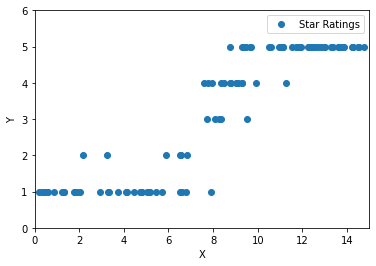

In [4]:
def generate_data_2(N,y_max=5,y_min=1):
  x_max = 15
  X = x_max*np.random.rand(N)
  p = np.exp(X-x_max/2)/(1+np.exp(X-x_max/2))

  Y = np.random.binomial(y_max-y_min, p, N) + y_min
  return X,Y

N = 100
X,Y = generate_data_2(N)
simple_plot(X,Y,'Star Ratings')
plt.axis([0,15,0,6])

In [19]:
print_data(X,Y)

5.14, 0.00
14.71, 1.00
9.45, 1.00
14.89, 1.00
12.06, 1.00
10.85, 1.00
6.25, 1.00
11.92, 1.00
0.88, 0.00
10.29, 0.00
5.92, 1.00
4.34, 0.00
6.38, 0.00
0.97, 0.00
14.54, 1.00
3.41, 0.00
3.38, 0.00
10.90, 1.00
4.59, 0.00
8.60, 1.00
12.36, 1.00
11.09, 1.00
2.75, 0.00
10.38, 1.00
1.49, 0.00
0.92, 0.00
12.45, 1.00
6.84, 1.00
7.16, 1.00
2.88, 0.00
12.62, 1.00
6.06, 0.00
14.48, 1.00
10.74, 1.00
10.33, 1.00
0.53, 0.00
8.64, 0.00
10.41, 1.00
9.64, 1.00
5.76, 0.00
14.02, 1.00
3.86, 0.00
8.33, 1.00
4.64, 0.00
9.60, 1.00
2.37, 0.00
13.18, 1.00
6.07, 0.00
7.84, 1.00
0.76, 0.00


# Example 3: 0-1 data



(0.0, 15.0, -0.5, 1.5)

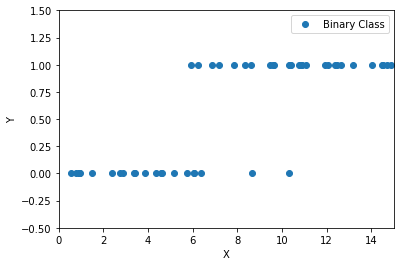

In [7]:
N = 50
X,Y = generate_data_2(N,y_min=0,y_max=1)

simple_plot(X,Y,'Binary Class')
plt.axis([0,15,-0.5,1.5])

Intercept: -6.289, Coef: 0.901


(0.0, 15.0, -0.5, 1.5)

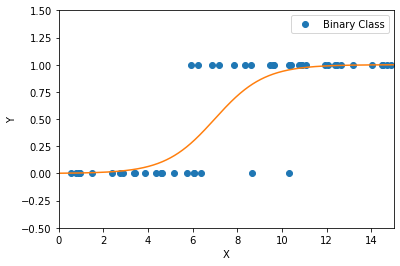

In [17]:
from sklearn.linear_model import LogisticRegression

glm_model = LogisticRegression(fit_intercept=True, C=1e9) # Large C for no regularization
glm_fit = glm_model.fit(X.reshape(N,1), Y)
print(f"Intercept: {glm_fit.intercept_.item():.3f}, Coef: {glm_fit.coef_.item():.3f}")

x_axis = np.linspace(0,15,1000)
simple_plot(X,Y,'Binary Class')
sigmoid = lambda x : np.exp(x)/(1+np.exp(x))
plt.plot(x_axis,sigmoid(glm_fit.coef_.item()*x_axis + glm_fit.intercept_.item()))
plt.axis([0,15,-0.5,1.5])

In [8]:
print_data(X,Y)

5.14, 0.00
14.71, 1.00
9.45, 1.00
14.89, 1.00
12.06, 1.00
10.85, 1.00
6.25, 1.00
11.92, 1.00
0.88, 0.00
10.29, 0.00
5.92, 1.00
4.34, 0.00
6.38, 0.00
0.97, 0.00
14.54, 1.00
3.41, 0.00
3.38, 0.00
10.90, 1.00
4.59, 0.00
8.60, 1.00
12.36, 1.00
11.09, 1.00
2.75, 0.00
10.38, 1.00
1.49, 0.00
0.92, 0.00
12.45, 1.00
6.84, 1.00
7.16, 1.00
2.88, 0.00
12.62, 1.00
6.06, 0.00
14.48, 1.00
10.74, 1.00
10.33, 1.00
0.53, 0.00
8.64, 0.00
10.41, 1.00
9.64, 1.00
5.76, 0.00
14.02, 1.00
3.86, 0.00
8.33, 1.00
4.64, 0.00
9.60, 1.00
2.37, 0.00
13.18, 1.00
6.07, 0.00
7.84, 1.00
0.76, 0.00
